<a href="https://colab.research.google.com/github/Zeldano118/QPon_NLP_PBA/blob/main/assignments/week%202/1_Week2_Scrapping_QPon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Scrapping Google Apps Review - QPon
Re-run of Week 2 scrapping notebook using QPon app reviews.

App: [QPon](https://play.google.com/store/apps/details?id=com.qpon.platform) (`com.qpon.platform`)

In [1]:
!pip install google_play_scraper textblob seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00


In [2]:
from google_play_scraper import app, Sort, reviews_all
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from pathlib import Path
import nltk
import string
import re
import time

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

True

In [3]:
# QPon app from Google Play
# https://play.google.com/store/apps/details?id=com.qpon.platform
qpon_reviews = reviews_all(
    'com.qpon.platform',
    sleep_milliseconds=0,
    lang='id',
    country='id',
    sort=Sort.MOST_RELEVANT,
)
print(f'{len(qpon_reviews):,} reviews scraped')

4,698 reviews scraped


In [4]:
df = pd.DataFrame(np.array(qpon_reviews), columns=['content'])
df = df.join(pd.DataFrame(df.pop('content').tolist()))
df.to_csv('df_qpon_rev.csv', index=False)
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,85c1f968-1c50-4eb0-a84e-c4fdea4ac20d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tidak bisa login (alasan aktivitas mencurigaka...,1,173,2.21.0.1,2026-01-11 13:44:34,None,NaT,2.21.0.1
1,36aaf78f-66de-4b14-9adc-21575d7a94a3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi log out dengan sendirinya, pas login ...",1,81,2.21.0.1,2026-01-16 05:05:27,None,NaT,2.21.0.1
2,9a0b398e-d7b1-4679-a4d4-97f7aa47f9f6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kapok deh Awal doang enak . sekarang2 mau orde...,1,39,2.21.0.1,2026-01-11 04:31:11,None,NaT,2.21.0.1
3,bbb8121f-b69b-4d6e-85bf-4fe193fe0458,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,semenjak update selalu force Close ketika memi...,1,1,2.24.0.1,2026-03-16 11:10:56,None,NaT,2.24.0.1
4,1d499b55-883c-422c-a83e-0a181330fd97,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi banyak error. perkara ganti hape dibi...,1,4,2.24.0.1,2026-03-10 08:43:02,None,NaT,2.24.0.1
...,...,...,...,...,...,...,...,...,...,...,...
4693,d7f04849-41fa-4319-b2aa-56e3947d1c20,Khanza Khairunnisa,https://play-lh.googleusercontent.com/a/ACg8oc...,mantapp👍🏼👍🏼👍🏼👍🏼,5,0,None,2026-03-22 23:12:23,None,NaT,None
4694,827f7dc8-944f-4cf4-ac7a-d83302f0767e,Juliant Candra,https://play-lh.googleusercontent.com/a/ACg8oc...,🙏🙏🙏,5,0,None,2025-12-13 18:51:40,None,NaT,None
4695,20d1d5b6-f366-4869-a44c-a993e9e53dec,Uchei Angraeni,https://play-lh.googleusercontent.com/a-/ALV-U...,👍,5,0,None,2026-01-17 04:18:45,None,NaT,None
4696,74dba772-c881-40a4-971f-8a73471cdbba,By-you Creations,https://play-lh.googleusercontent.com/a-/ALV-U...,👎👎👎👎👎👎👎👎👎👎,1,0,None,2025-07-03 11:14:34,Terima kasih atas ulasannya. Mohon maaf buat p...,2025-07-07 04:32:27,None


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4698 entries, 0 to 4697
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              4698 non-null   object        
 1   userName              4698 non-null   object        
 2   userImage             4698 non-null   object        
 3   content               4698 non-null   object        
 4   score                 4698 non-null   int64         
 5   thumbsUpCount         4698 non-null   int64         
 6   reviewCreatedVersion  3654 non-null   object        
 7   at                    4698 non-null   datetime64[ns]
 8   replyContent          2768 non-null   object        
 9   repliedAt             2768 non-null   datetime64[ns]
 10  appVersion            3654 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 403.9+ KB


In [6]:
df_analysis = df.loc[:, ['content', 'score', 'thumbsUpCount',
                         'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt']]
df_analysis

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,tidak bisa login (alasan aktivitas mencurigaka...,1,173,2.21.0.1,2026-01-11 13:44:34,None,NaT
1,"aplikasi log out dengan sendirinya, pas login ...",1,81,2.21.0.1,2026-01-16 05:05:27,None,NaT
2,kapok deh Awal doang enak . sekarang2 mau orde...,1,39,2.21.0.1,2026-01-11 04:31:11,None,NaT
3,semenjak update selalu force Close ketika memi...,1,1,2.24.0.1,2026-03-16 11:10:56,None,NaT
4,aplikasi banyak error. perkara ganti hape dibi...,1,4,2.24.0.1,2026-03-10 08:43:02,None,NaT
...,...,...,...,...,...,...,...
4693,mantapp👍🏼👍🏼👍🏼👍🏼,5,0,None,2026-03-22 23:12:23,None,NaT
4694,🙏🙏🙏,5,0,None,2025-12-13 18:51:40,None,NaT
4695,👍,5,0,None,2026-01-17 04:18:45,None,NaT
4696,👎👎👎👎👎👎👎👎👎👎,1,0,None,2025-07-03 11:14:34,Terima kasih atas ulasannya. Mohon maaf buat p...,2025-07-07 04:32:27


In [7]:
df['score'].value_counts()

,count
score,
1,2064
5,2064
2,269
3,170
4,131


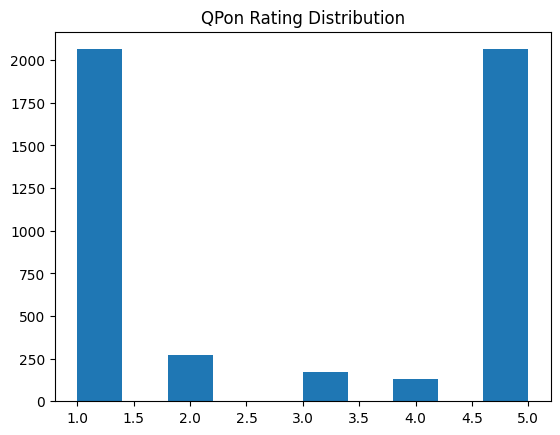

In [8]:
plt.hist(df['score'])
plt.title('QPon Rating Distribution')
plt.show()

In [9]:
!pip install emoji wordcloud -q

import emoji
from nltk import word_tokenize
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 18.1 MB/s eta 0:00:00


True

In [10]:
# sentiment polarity using TextBlob
df['sentiment_polarity'] = df['content'].astype(str).apply(lambda x: TextBlob(x).polarity)
df['sentiment_subjective'] = df['content'].astype(str).apply(lambda x: TextBlob(x).subjectivity)
df.loc[:, ['content', 'score', 'sentiment_polarity', 'sentiment_subjective']]

,content,score,sentiment_polarity,sentiment_subjective
0,tidak bisa login (alasan aktivitas mencurigaka...,1,0.000000,0.000000
1,"aplikasi log out dengan sendirinya, pas login ...",1,0.000000,0.000000
2,kapok deh Awal doang enak . sekarang2 mau orde...,1,0.433333,0.833333
3,semenjak update selalu force Close ketika memi...,1,0.150000,0.650000
4,aplikasi banyak error. perkara ganti hape dibi...,1,0.000000,0.000000
...,...,...,...,...
4693,mantapp👍🏼👍🏼👍🏼👍🏼,5,0.000000,0.000000
4694,🙏🙏🙏,5,0.000000,0.000000
4695,👍,5,0.000000,0.000000
4696,👎👎👎👎👎👎👎👎👎👎,1,0.000000,0.000000


## Lowercasing

In [11]:
df['content'] = df['content'].astype(str)
print('Before:')
print(df['content'][0])
print(df['content'][1])
print(df['content'][2])

Before:
tidak bisa login (alasan aktivitas mencurigakan). Jawaban CS terlalu template dan tidak ada solusi yang diberikan. sayang disayangkan, sudah banyak sekali di review ini maupun di web yang protes terkait hal/ kasus serupa (tidak bisa login dan tidak ada solusi dr CS) tapi tidak ada perbaikan sama sekali. Padahal apps krusial kek mbanking atau e-wallet sj ga seribet ini, tinggal verifikasi ulang kalau sesuai dah beres lagi.
aplikasi log out dengan sendirinya, pas login ulang gabisa dengan alasan aktivitas mencurigakan. padahal gapernah login dengan device lain. baca review ternyata banyak case sama, tidak ada penyelesaian, jawaban CS tidak ada solusi yg baik hanya menjawab berdasarkan sistem. padahal sistem yg buat juga manusi, tapi kalian gabisa meintenance sistem.kalian dg baik.. diminta tunggu 3x24 jam lah, login ulang lah, sdh uninistal, login ulang, sdh berbulan bulan, masih sama. NIHIL
kapok deh Awal doang enak . sekarang2 mau order aja susah bgt alasannya produk habis lah,

In [12]:
df['content'] = df['content'].apply(lambda x: x.lower())
print('After lowercasing:')
print(df['content'][0])
print(df['content'][1])
print(df['content'][2])

After lowercasing:
tidak bisa login (alasan aktivitas mencurigakan). jawaban cs terlalu template dan tidak ada solusi yang diberikan. sayang disayangkan, sudah banyak sekali di review ini maupun di web yang protes terkait hal/ kasus serupa (tidak bisa login dan tidak ada solusi dr cs) tapi tidak ada perbaikan sama sekali. padahal apps krusial kek mbanking atau e-wallet sj ga seribet ini, tinggal verifikasi ulang kalau sesuai dah beres lagi.
aplikasi log out dengan sendirinya, pas login ulang gabisa dengan alasan aktivitas mencurigakan. padahal gapernah login dengan device lain. baca review ternyata banyak case sama, tidak ada penyelesaian, jawaban cs tidak ada solusi yg baik hanya menjawab berdasarkan sistem. padahal sistem yg buat juga manusi, tapi kalian gabisa meintenance sistem.kalian dg baik.. diminta tunggu 3x24 jam lah, login ulang lah, sdh uninistal, login ulang, sdh berbulan bulan, masih sama. nihil
kapok deh awal doang enak . sekarang2 mau order aja susah bgt alasannya produk

## Stopwords Removal
Indonesian Stopwords

In [13]:
indonesian_stopwords = stopwords.words('indonesian')
print(indonesian_stopwords[:20])

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


In [14]:
df['wordCount'] = [len(review.split()) for review in df['content']]
df['uppercaseCharCount'] = [sum(c.isupper() for c in review) for review in df['content']]
df['specialCharCount'] = [sum(c in string.punctuation for c in review) for review in df['content']]

df.loc[:, ['content', 'score', 'sentiment_polarity', 'sentiment_subjective',
           'wordCount', 'uppercaseCharCount', 'specialCharCount']]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,tidak bisa login (alasan aktivitas mencurigaka...,1,0.000000,0.000000,67,0,12
1,"aplikasi log out dengan sendirinya, pas login ...",1,0.000000,0.000000,70,0,16
2,kapok deh awal doang enak . sekarang2 mau orde...,1,0.433333,0.833333,50,0,8
3,semenjak update selalu force close ketika memi...,1,0.150000,0.650000,49,0,5
4,aplikasi banyak error. perkara ganti hape dibi...,1,0.000000,0.000000,77,0,10
...,...,...,...,...,...,...,...
4693,mantapp👍🏼👍🏼👍🏼👍🏼,5,0.000000,0.000000,1,0,0
4694,🙏🙏🙏,5,0.000000,0.000000,1,0,0
4695,👍,5,0.000000,0.000000,1,0,0
4696,👎👎👎👎👎👎👎👎👎👎,1,0.000000,0.000000,1,0,0


In [15]:
df['sentiment_rating'] = df['score'].apply(
    lambda x: 'Positive' if x > 3 else ('Neutral' if x == 3 else 'Negative')
)
df.loc[:, ['content', 'score', 'sentiment_polarity', 'sentiment_subjective', 'sentiment_rating']]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,tidak bisa login (alasan aktivitas mencurigaka...,1,0.000000,0.000000,Negative
1,"aplikasi log out dengan sendirinya, pas login ...",1,0.000000,0.000000,Negative
2,kapok deh awal doang enak . sekarang2 mau orde...,1,0.433333,0.833333,Negative
3,semenjak update selalu force close ketika memi...,1,0.150000,0.650000,Negative
4,aplikasi banyak error. perkara ganti hape dibi...,1,0.000000,0.000000,Negative
...,...,...,...,...,...
4693,mantapp👍🏼👍🏼👍🏼👍🏼,5,0.000000,0.000000,Positive
4694,🙏🙏🙏,5,0.000000,0.000000,Positive
4695,👍,5,0.000000,0.000000,Positive
4696,👎👎👎👎👎👎👎👎👎👎,1,0.000000,0.000000,Negative


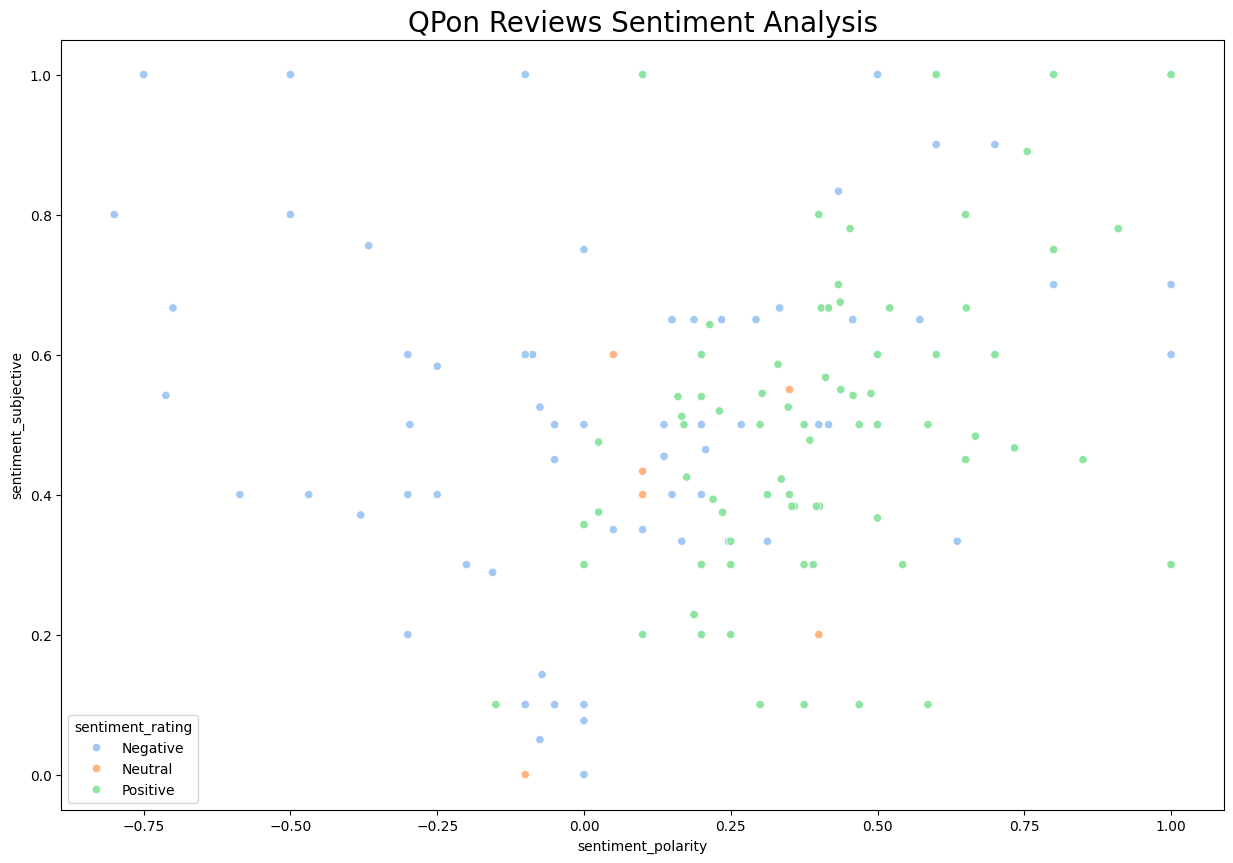

In [16]:
plt.figure(figsize=(15, 10))
sns.scatterplot(x=df['sentiment_polarity'], y=df['sentiment_subjective'],
                hue=df['sentiment_rating'], edgecolor='white', palette='pastel')
plt.title('QPon Reviews Sentiment Analysis', fontsize=20)
plt.show()

In [17]:
def freq_words(x, terms=30):
    all_words = ' '.join([text for text in x]).split()
    fdist = FreqDist(all_words)
    words_df = pd.DataFrame({'word': list(fdist.keys()), 'count': list(fdist.values())})
    d = words_df.nlargest(columns='count', n=terms)
    plt.figure(figsize=(20, 5))
    sns.barplot(data=d, x='word', y='count', palette='viridis')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top {terms} Most Frequent Words')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_5858/85699166.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=d, x='word', y='count', palette='viridis')


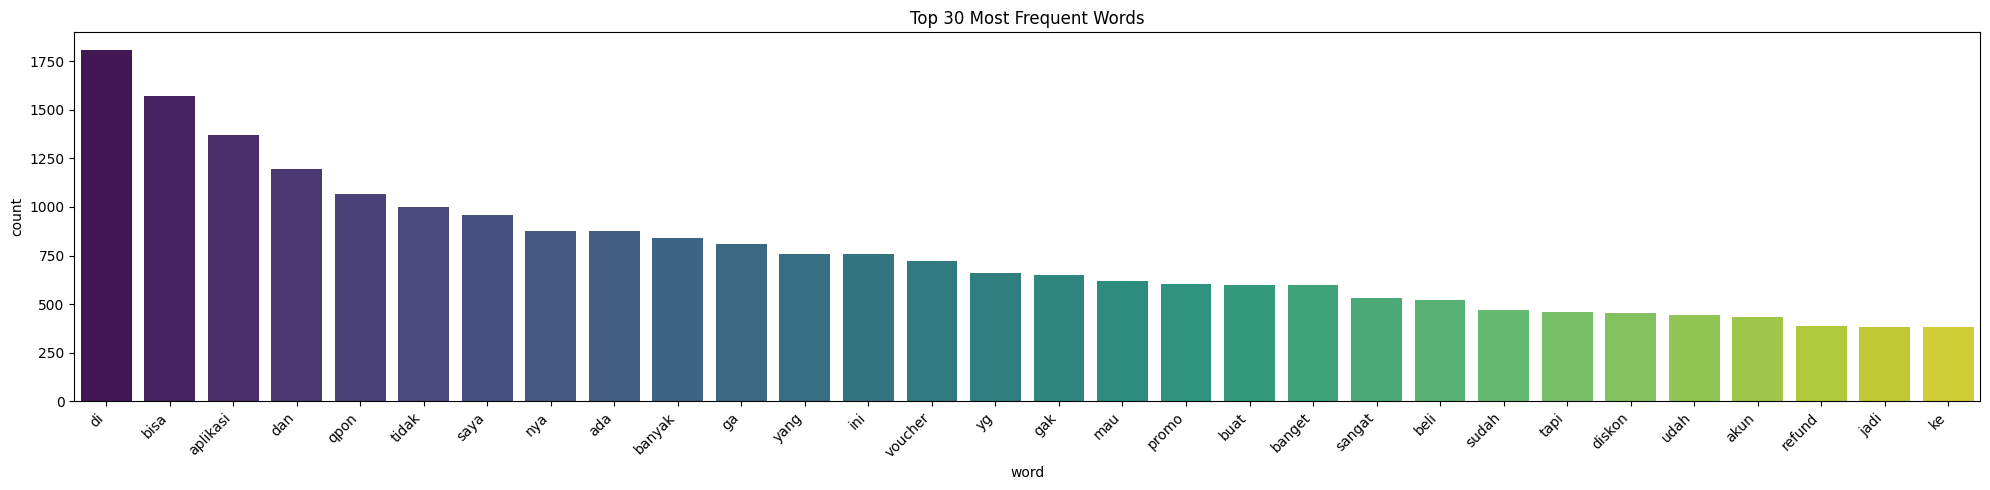

In [18]:
freq_words(df['content'])

In [19]:
!pip install Sastrawi -q
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()
df['content'] = df['content'].apply(lambda x: stopword_remover.remove(x))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.2 MB/s eta 0:00:00


In [20]:
# also remove English stopwords
english_stopwords = stopwords.words('english')
df['content'] = df['content'].apply(
    lambda x: ' '.join([w for w in x.split() if w not in english_stopwords])
)

In [21]:
df.loc[:, ['content', 'score', 'sentiment_polarity', 'sentiment_subjective', 'sentiment_rating']]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,login (alasan aktivitas mencurigakan). jawaban...,1,0.000000,0.000000,Negative
1,"aplikasi log sendirinya, pas login ulang gabis...",1,0.000000,0.000000,Negative
2,kapok deh awal doang enak . sekarang2 mau orde...,1,0.433333,0.833333,Negative
3,semenjak update selalu force close memilih men...,1,0.150000,0.650000,Negative
4,aplikasi banyak error. perkara ganti hape dibi...,1,0.000000,0.000000,Negative
...,...,...,...,...,...
4693,mantapp👍🏼👍🏼👍🏼👍🏼,5,0.000000,0.000000,Positive
4694,🙏🙏🙏,5,0.000000,0.000000,Positive
4695,👍,5,0.000000,0.000000,Positive
4696,👎👎👎👎👎👎👎👎👎👎,1,0.000000,0.000000,Negative


/tmp/ipykernel_5858/85699166.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=d, x='word', y='count', palette='viridis')


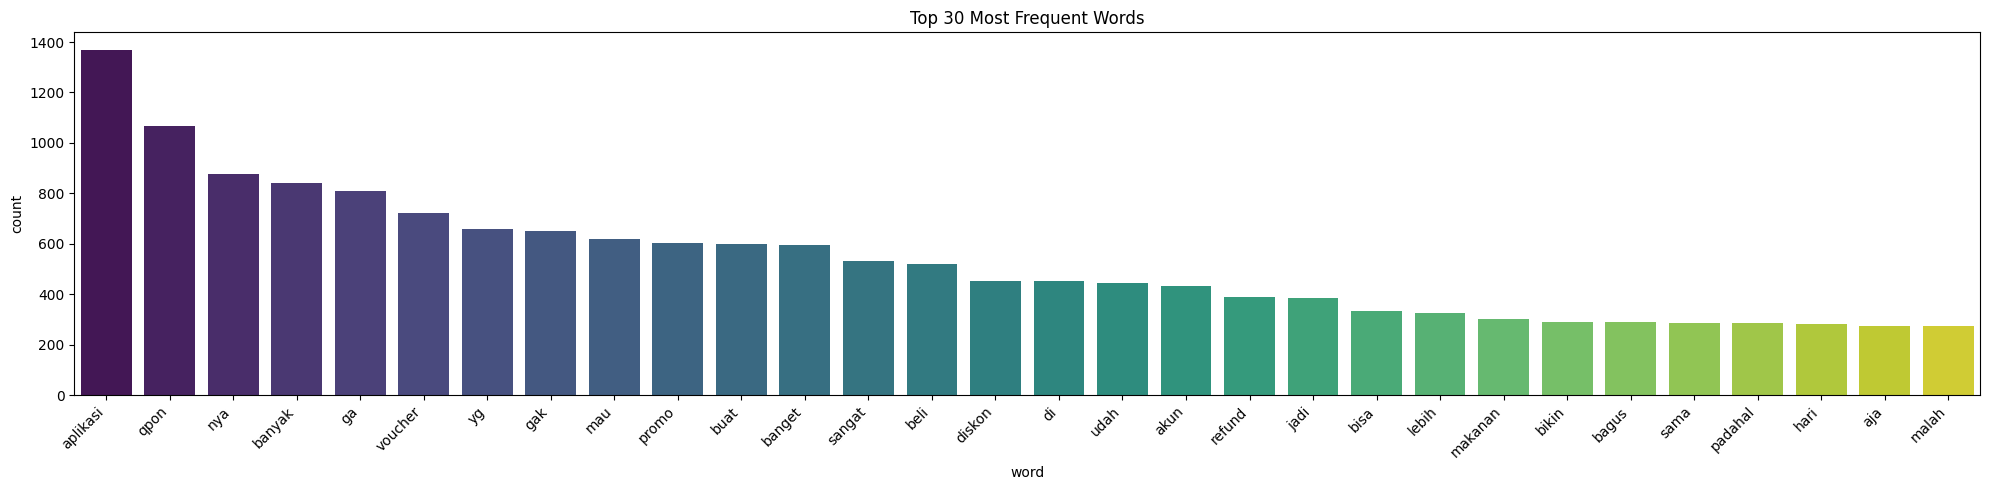

In [22]:
freq_words(df['content'])

### Analysis
After stopword removal (Indonesian + English), the frequent words shift from common function words to more meaningful terms related to QPon's features and user complaints.